# Energy Systems Forecasting - Best Models Implementation
## Top Performing Models for PV, Combined Load, and Separated Load

This notebook is a streamlined implementation focused entirely on training and evaluating the best-performing models (Optimized XGBoost) for PV, aggregated load, and separated component load forecasting.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# 1. Library Imports & Environment Setup
# ═══════════════════════════════════════════════════════════════════════════
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

# Reproducibility Seed
SEED = 42
np.random.seed(SEED)

# Data Directory
DATA_DIR = os.path.join("..", "data")
print(f"Data directory: {os.path.abspath(DATA_DIR)}")

# Plotting config
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("husl")
print("Libraries loaded successfully.")

Data directory: c:\Users\doron\Documents\TU Delft\Q3\Digital Twins SET3120\GitHub\SET3120---Energy-Systems-Simulation-Digital-Twins\data
Libraries loaded successfully.


## 2. Data Ingestion & Aggregation
Load raw per-customer CSV datasets, aggregate them to grid-level totals, and calculate `total_load_kW` and `net_load_kW`.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# 2. Data Ingestion & Aggregation
# ═══════════════════════════════════════════════════════════════════════════

def load_profile(filename, date_col="date"):
    """Load per-customer time-series CSV and parse datetime index."""
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, index_col=date_col, parse_dates=True)
    return df

print("Loading raw profiles...")
cons_df = load_profile("consumption_one_year_15min.csv")
ev_df   = load_profile("ev_one_year_15min.csv")
pv_df   = load_profile("pv_one_year_15min.csv")

# Aggregate grid-level profiles
df_raw = pd.DataFrame({
    "consumption_kW": cons_df.sum(axis=1),
    "ev_kW": ev_df.sum(axis=1),
    "pv_generation_kW": pv_df.sum(axis=1),
})

# Create main targets
df_raw["total_load_kW"] = df_raw["consumption_kW"] + df_raw["ev_kW"]
df_raw["net_load_kW"]   = df_raw["total_load_kW"] - df_raw["pv_generation_kW"]

print(f"Data shape after aggregation: {df_raw.shape}")
print(df_raw.head())

Loading raw profiles...
Data shape after aggregation: (35040, 5)
                     consumption_kW  ev_kW  pv_generation_kW  total_load_kW  \
date                                                                          
2020-01-01 00:00:00       13.697405    0.0               0.0      13.697405   
2020-01-01 00:15:00       13.697405    0.0               0.0      13.697405   
2020-01-01 00:30:00       13.697405    0.0               0.0      13.697405   
2020-01-01 00:45:00       13.697405    0.0               0.0      13.697405   
2020-01-01 01:00:00       11.628291    0.0               0.0      11.628291   

                     net_load_kW  
date                              
2020-01-01 00:00:00    13.697405  
2020-01-01 00:15:00    13.697405  
2020-01-01 00:30:00    13.697405  
2020-01-01 00:45:00    13.697405  
2020-01-01 01:00:00    11.628291  


## 3. Feature Engineering & Train-Test Split
Apply the engineered feature extraction functions, incorporating calendar features, cyclical encodings, lag features, rolling statistics, and solar elevation. Perform an 80/20 chronological split.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# 3. Feature Engineering & Train-Test Split
# ═══════════════════════════════════════════════════════════════════════════

def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    feat = df_in.copy()
    idx = feat.index
    
    # Calendar features
    feat["step_of_day"] = np.arange(len(feat)) % 96
    feat["day_of_week"] = idx.dayofweek.values
    feat["day_of_year"] = idx.dayofyear.values
    feat["hour_of_day"] = idx.hour.values
    feat["is_weekend"]  = (feat["day_of_week"] >= 5).astype(int)
    feat["month"]       = idx.month.values
    feat["minutes_from_midnight"] = idx.hour.values * 60 + idx.minute.values
    
    # Cyclical encodings
    feat["sin_hour"] = np.sin(2 * np.pi * feat["hour_of_day"] / 24)
    feat["cos_hour"] = np.cos(2 * np.pi * feat["hour_of_day"] / 24)
    feat["sin_dow"]  = np.sin(2 * np.pi * feat["day_of_week"] / 7)
    feat["cos_dow"]  = np.cos(2 * np.pi * feat["day_of_week"] / 7)
    feat["sin_doy"]  = np.sin(2 * np.pi * feat["day_of_year"] / 365)
    feat["cos_doy"]  = np.cos(2 * np.pi * feat["day_of_year"] / 365)
    
    # Lag features
    for lag in [1, 4, 96, 672]:
        for col in ["total_load_kW", "pv_generation_kW", "net_load_kW", "ev_kW", "consumption_kW"]:
            feat[f"{col}_lag{lag}"] = feat[col].shift(lag)
    
    # Rolling statistics
    feat["load_roll_mean_4h"]  = feat["total_load_kW"].rolling(window=16).mean()
    feat["load_roll_std_4h"]   = feat["total_load_kW"].rolling(window=16).std()
    feat["pv_roll_mean_4h"]    = feat["pv_generation_kW"].rolling(window=16).mean()
    feat["load_roll_mean_24h"] = feat["total_load_kW"].rolling(window=96).mean()
    feat["load_roll_std_24h"]  = feat["total_load_kW"].rolling(window=96).std()
    feat["pv_roll_sum_24h"]    = feat["pv_generation_kW"].rolling(window=96).sum()
    
    # EV rolling stats
    ev_shift = feat["ev_kW"].shift(1)
    feat["ev_roll_sum_96"] = ev_shift.rolling(96).sum() * (15 / 60)
    ev_roll_max_96 = ev_shift.rolling(96).max()
    feat["ev_peak_ratio"] = np.clip(feat["ev_kW"] / (ev_roll_max_96 + 1.0), 0.0, 1.5)
    
    # Seasonal features
    month_arr = feat["month"].values
    season_arr = np.where(np.isin(month_arr, [12, 1, 2]), 0,
                 np.where(np.isin(month_arr, [3, 4, 5]), 1,
                 np.where(np.isin(month_arr, [6, 7, 8]), 2, 3)))
    feat["season"]     = season_arr
    feat["is_winter"]  = (season_arr == 0).astype(int)
    feat["is_summer"]  = (season_arr == 2).astype(int)
    feat["sin_season"] = np.sin(2 * np.pi * season_arr / 4)
    feat["cos_season"] = np.cos(2 * np.pi * season_arr / 4)

    # Solar elevation
    LATITUDE_RAD = np.radians(52.0)
    mfm = feat["minutes_from_midnight"].values
    doy = feat["day_of_year"].values.astype(float)
    declination = np.radians(23.45 * np.sin(np.radians(360.0 / 365.0 * (doy - 81))))
    hour_angle = 2.0 * np.pi * (mfm - 720.0) / 1440.0
    sin_elev = np.sin(LATITUDE_RAD) * np.sin(declination) + np.cos(LATITUDE_RAD) * np.cos(declination) * np.cos(hour_angle)
    elevation_rad = np.arcsin(np.clip(sin_elev, -1.0, 1.0))
    feat["solar_elevation"] = elevation_rad
    feat["solar_elevation_positive"] = np.maximum(0.0, elevation_rad)
    
    feat.dropna(inplace=True)
    return feat

df_feat = engineer_features(df_raw)
original_signals = ["consumption_kW", "ev_kW", "pv_generation_kW", "total_load_kW", "net_load_kW"]
FEATURE_COLS = [c for c in df_feat.columns if c not in original_signals]
print(f"Features engineered: {len(FEATURE_COLS)}")

# Train-Test Split (80/20 chronological)
SPLIT_FRAC = 0.80
split_idx = int(len(df_feat) * SPLIT_FRAC)

train_df = df_feat.iloc[:split_idx]
test_df  = df_feat.iloc[split_idx:]

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

Features engineered: 48
Train samples: 27494
Test samples: 6874


## 4. Tensor Preparation & MinMax Scaling
Fit distinct `MinMaxScaler` instances for each target variable purely on the training set. Transform features.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# 4. Tensor Preparation & MinMax Scaling
# ═══════════════════════════════════════════════════════════════════════════

scaler_X = MinMaxScaler(feature_range=(0, 1))

targets_dict = {}
for target_name in ["total_load_kW", "pv_generation_kW", "consumption_kW", "ev_kW"]:
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    y_train_raw = train_df[target_name].values.reshape(-1, 1)
    y_test_raw  = test_df[target_name].values.reshape(-1, 1)
    
    # Scale only on train to prevent leakage
    y_train_scaled = scaler_y.fit_transform(y_train_raw).ravel()
    y_test_scaled  = scaler_y.transform(y_test_raw).ravel()
    
    targets_dict[target_name] = {
        "y_train_orig": y_train_raw.ravel(),
        "y_test_orig": y_test_raw.ravel(),
        "y_train_scaled": y_train_scaled,
        "y_test_scaled": y_test_scaled,
        "scaler": scaler_y,
    }

# Extract and scale features
X_train_raw = train_df[FEATURE_COLS].values
X_test_raw  = test_df[FEATURE_COLS].values

X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)

print(f"Feature matrix (X) shape: Train {X_train.shape}, Test {X_test.shape}")
print("Scaling complete for features and all targets.")

Feature matrix (X) shape: Train (27494, 48), Test (6874, 48)
Scaling complete for features and all targets.


## 5. Top Model Training: PV Generation
From cross-validation in the tuning notebook, the best selected modeling approach for PV Generation is **XGBoost** with `max_depth=3`, `learning_rate=0.1`, and `subsample=0.8`.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# 5. Top Model Training: PV Generation
# ═══════════════════════════════════════════════════════════════════════════

print("─"*80)
print("TRAINING TOP MODEL: PV GENERATION (XGBoost)")
print("─"*80)

xgb_pv = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t_start = time.time()
xgb_pv.fit(
    X_train, targets_dict["pv_generation_kW"]["y_train_orig"],
    eval_set=[(X_test, targets_dict["pv_generation_kW"]["y_test_orig"])],
    verbose=False
)
t_train_pv = time.time() - t_start

y_pred_pv = xgb_pv.predict(X_test)
print(f"PV Model Training complete in {t_train_pv:.2f} seconds")

────────────────────────────────────────────────────────────────────────────────
TRAINING TOP MODEL: PV GENERATION (XGBoost)
────────────────────────────────────────────────────────────────────────────────
PV Model Training complete in 0.67 seconds


## 6. Top Model Training: Combined Load
The optimally tuned model for combined system load tracking (`total_load_kW`) utilizes **XGBoost** with `max_depth=6`, `learning_rate=0.1`, and `subsample=1.0`.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# 6. Top Model Training: Combined Load
# ═══════════════════════════════════════════════════════════════════════════

print("─"*80)
print("TRAINING TOP MODEL: COMBINED LOAD (XGBoost)")
print("─"*80)

xgb_load = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t_start = time.time()
xgb_load.fit(
    X_train, targets_dict["total_load_kW"]["y_train_orig"],
    eval_set=[(X_test, targets_dict["total_load_kW"]["y_test_orig"])],
    verbose=False
)
t_train_load = time.time() - t_start

y_pred_load = xgb_load.predict(X_test)
print(f"Combined Load Model Training complete in {t_train_load:.2f} seconds")

────────────────────────────────────────────────────────────────────────────────
TRAINING TOP MODEL: COMBINED LOAD (XGBoost)
────────────────────────────────────────────────────────────────────────────────
Combined Load Model Training complete in 1.16 seconds


## 7. Top Model Training: Separated Load (Base Consumption & EV)
We instantiate two discrete top-tier models for `consumption_kW` and `ev_kW`. Both models employ the identical optimal hyperparameter configuration derived for the overall combined load forecasting structure (`max_depth=6`, `learning_rate=0.1`, `subsample=1.0`).

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# 7. Top Model Training: Separated Load (Consumption & EV)
# ═══════════════════════════════════════════════════════════════════════════

print("─"*80)
print("TRAINING TOP MODELS: SEPARATED LOAD (XGBoost)")
print("─"*80)

# Base Consumption Model
xgb_cons = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t_start = time.time()
xgb_cons.fit(
    X_train, targets_dict["consumption_kW"]["y_train_orig"],
    eval_set=[(X_test, targets_dict["consumption_kW"]["y_test_orig"])],
    verbose=False
)
t_train_cons = time.time() - t_start
y_pred_cons = xgb_cons.predict(X_test)
print(f"Consumption Model Training complete in {t_train_cons:.2f} seconds")

# EV Model
xgb_ev = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t_start = time.time()
xgb_ev.fit(
    X_train, targets_dict["ev_kW"]["y_train_orig"],
    eval_set=[(X_test, targets_dict["ev_kW"]["y_test_orig"])],
    verbose=False
)
t_train_ev = time.time() - t_start
y_pred_ev = xgb_ev.predict(X_test)
print(f"EV Model Training complete in {t_train_ev:.2f} seconds")

────────────────────────────────────────────────────────────────────────────────
TRAINING TOP MODELS: SEPARATED LOAD (XGBoost)
────────────────────────────────────────────────────────────────────────────────
Consumption Model Training complete in 0.53 seconds
EV Model Training complete in 0.51 seconds


## 8. Evaluation & Prediction Visualization
Calculate final regression metrics (MAE, RMSE, R²) for all trained models. We then plot a 3-day sample window comparing ground truth against predictions for each target to demonstrate qualitative model performance.

────────────────────────────────────────────────────────────────────────────────
FINAL MODEL METRICS
────────────────────────────────────────────────────────────────────────────────
  Model                 Target  MAE  RMSE     R2
XGBoost          PV Generation 9.24 22.41 0.8694
XGBoost Combined Load (Direct) 1.92  3.02 0.9729
XGBoost Combined Load (Summed) 1.88  2.97 0.9739
XGBoost            Consumption 1.25  2.03 0.9649
XGBoost                EV Load 1.07  2.20 0.9687

Consistency check (Separated vs. Combined):
Mean absolute difference between Direct and Summed Forecasts: 1.2148 kW


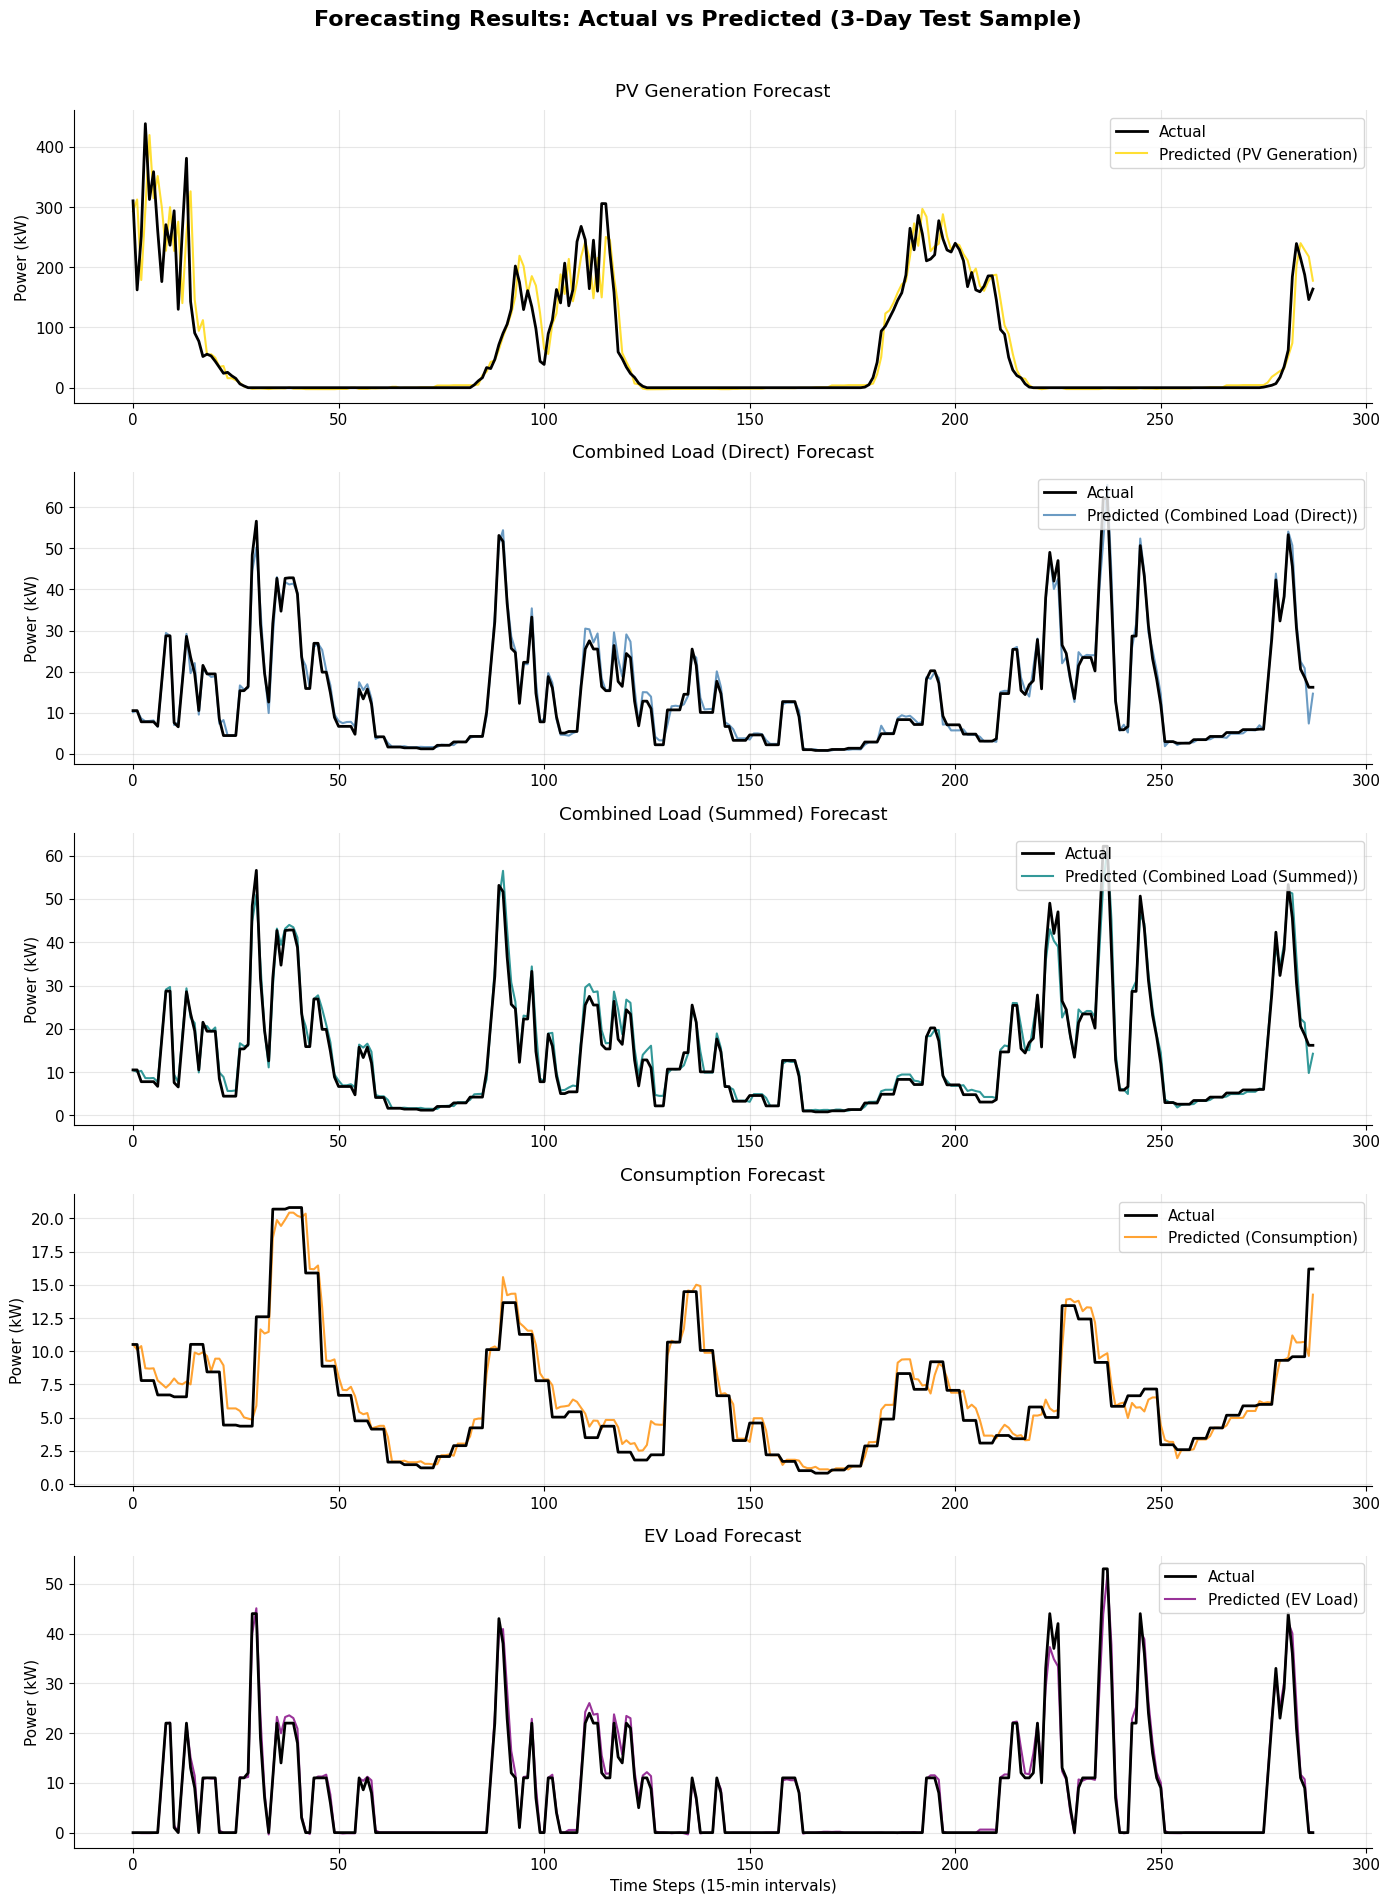

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 8. Evaluation & Prediction Visualization
# ═══════════════════════════════════════════════════════════════════════════

def evaluate_model(y_true, y_pred, model_name, target_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"Model": model_name, "Target": target_name, "MAE": mae, "RMSE": rmse, "R2": r2}

# Compute the sum of the separated models (Consumption + EV)
y_pred_separated_sum = y_pred_cons + y_pred_ev

# Compute all metrics
results = [
    evaluate_model(targets_dict["pv_generation_kW"]["y_test_orig"], y_pred_pv, "XGBoost", "PV Generation"),
    evaluate_model(targets_dict["total_load_kW"]["y_test_orig"], y_pred_load, "XGBoost", "Combined Load (Direct)"),
    evaluate_model(targets_dict["total_load_kW"]["y_test_orig"], y_pred_separated_sum, "XGBoost", "Combined Load (Summed)"),
    evaluate_model(targets_dict["consumption_kW"]["y_test_orig"], y_pred_cons, "XGBoost", "Consumption"),
    evaluate_model(targets_dict["ev_kW"]["y_test_orig"], y_pred_ev, "XGBoost", "EV Load"),
]

df_results = pd.DataFrame(results)

print("─"*80)
print("FINAL MODEL METRICS")
print("─"*80)
display_df = df_results.copy()
display_df["MAE"] = display_df["MAE"].map(lambda x: f"{x:.2f}")
display_df["RMSE"] = display_df["RMSE"].map(lambda x: f"{x:.2f}")
display_df["R2"] = display_df["R2"].map(lambda x: f"{x:.4f}")
print(display_df.to_string(index=False))
print("\nConsistency check (Separated vs. Combined):")
residual = np.mean(np.abs(y_pred_load - y_pred_separated_sum))
print(f"Mean absolute difference between Direct and Summed Forecasts: {residual:.4f} kW")

# ───────────────────────────────────────────────────────────────────────────
# Plots
# ───────────────────────────────────────────────────────────────────────────
sample_len = 3 * 96  # 3 days
t_sample = np.arange(sample_len)

fig, axes = plt.subplots(5, 1, figsize=(14, 20))
fig.suptitle("Forecasting Results: Actual vs Predicted (3-Day Test Sample)", fontsize=16, fontweight="bold")

targets = [
    (targets_dict["pv_generation_kW"]["y_test_orig"], y_pred_pv, "PV Generation", "gold"),
    (targets_dict["total_load_kW"]["y_test_orig"], y_pred_load, "Combined Load (Direct)", "steelblue"),
    (targets_dict["total_load_kW"]["y_test_orig"], y_pred_separated_sum, "Combined Load (Summed)", "teal"),
    (targets_dict["consumption_kW"]["y_test_orig"], y_pred_cons, "Consumption", "darkorange"),
    (targets_dict["ev_kW"]["y_test_orig"], y_pred_ev, "EV Load", "purple")
]

for idx, (y_test_orig, y_pred, name, color) in enumerate(targets):
    ax = axes[idx]
    y_test_slice = y_test_orig[:sample_len]
    y_pred_slice = y_pred[:sample_len]
    
    ax.plot(t_sample, y_test_slice, color="black", linewidth=2, label="Actual", zorder=3)
    ax.plot(t_sample, y_pred_slice, color=color, linewidth=1.5, alpha=0.8, label=f"Predicted ({name})")
    
    ax.set_title(f"{name} Forecast", pad=10)
    ax.set_ylabel("Power (kW)")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    if idx == 4:
        ax.set_xlabel("Time Steps (15-min intervals)")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## 9. Feature Importance Analysis
Interpret the models by analyzing the XGBoost feature importance scores for each trained model. This helps us understand which features drive the predictions for PV Generation, Combined Load, Consumption, and EV Load.

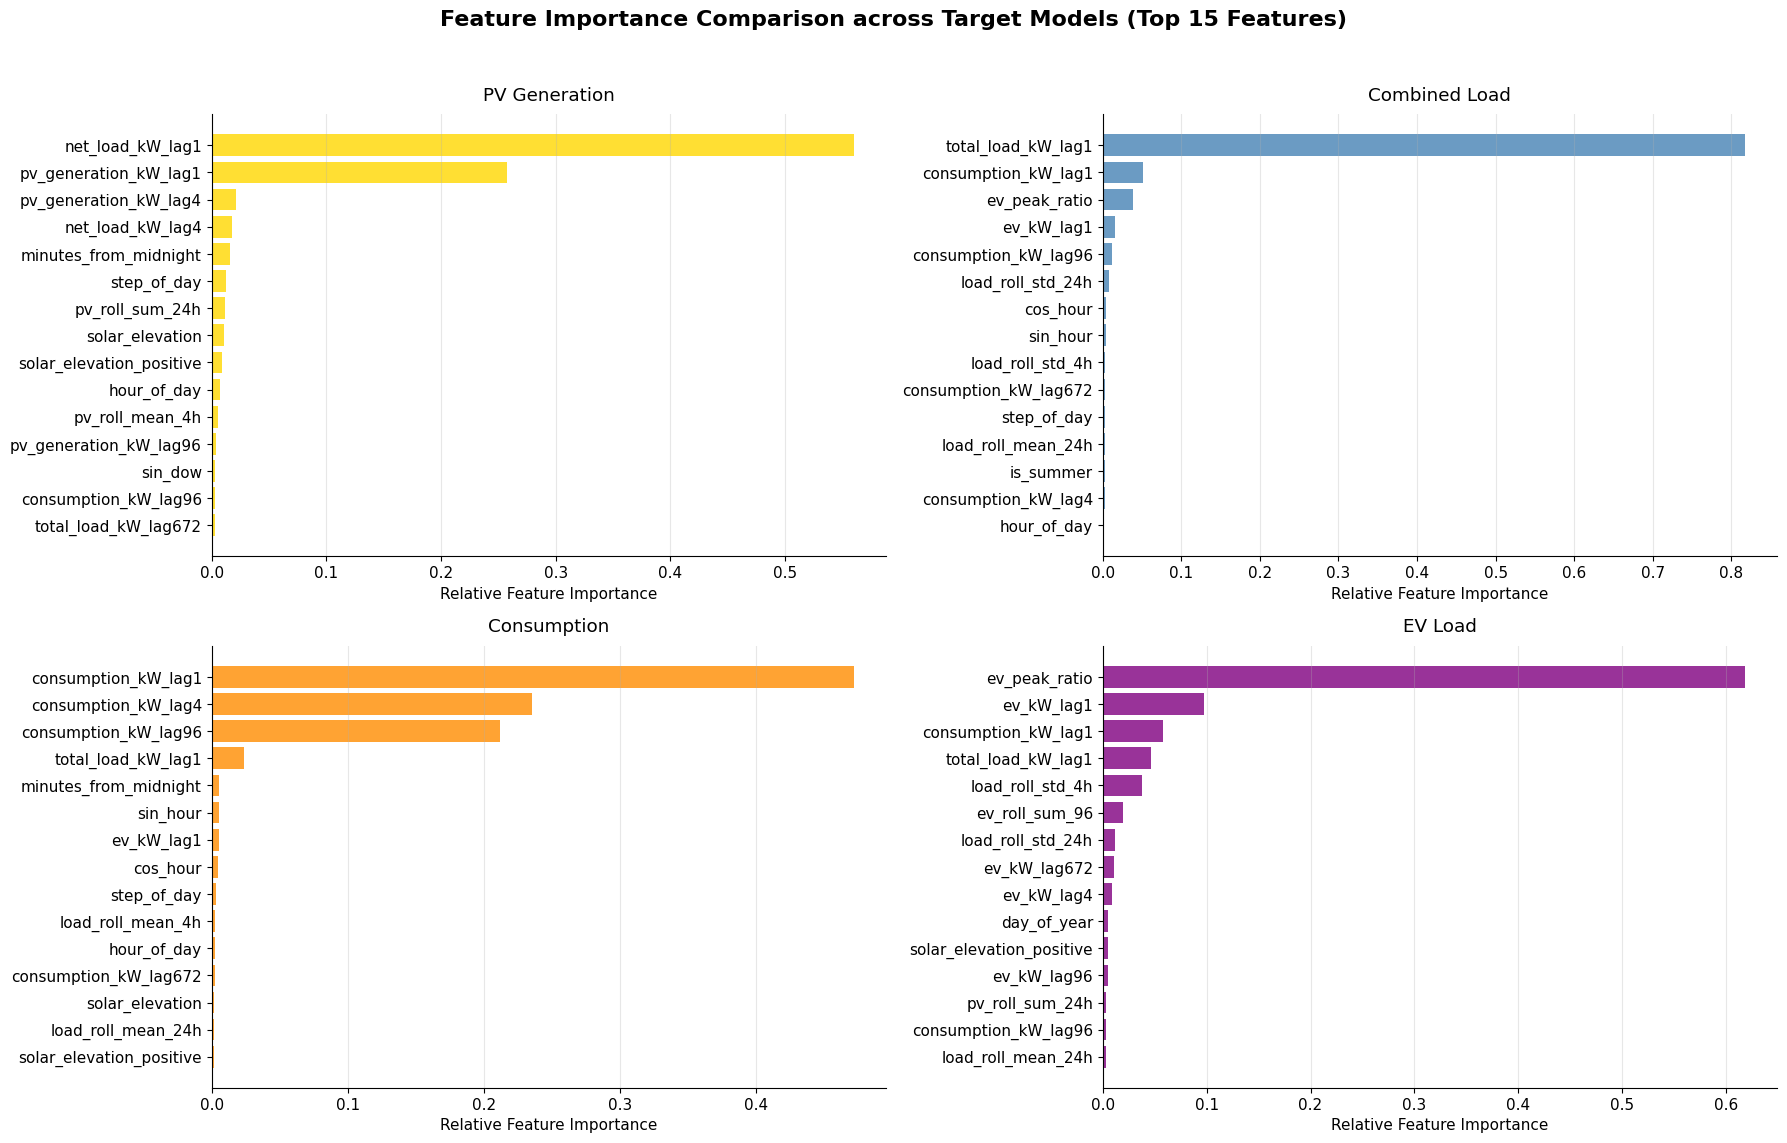

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# 9. Feature Importance Analysis
# ═══════════════════════════════════════════════════════════════════════════

def plot_feature_importance(model, feature_names, title, ax, color="steelblue", top_n=15):
    """Plot top N feature importances for an XGBoost model."""
    importance = model.feature_importances_
    
    # Sort indices by importance
    sorted_idx = np.argsort(importance)[-top_n:]
    
    ax.barh(range(top_n), importance[sorted_idx], align="center", color=color, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel("Relative Feature Importance")
    ax.set_title(title, pad=10)
    ax.grid(axis="x", alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Feature Importance Comparison across Target Models (Top 15 Features)", fontsize=16, fontweight="bold")

# Plot each model
plot_feature_importance(xgb_pv, FEATURE_COLS, "PV Generation", axes[0, 0], color="gold")
plot_feature_importance(xgb_load, FEATURE_COLS, "Combined Load", axes[0, 1], color="steelblue")
plot_feature_importance(xgb_cons, FEATURE_COLS, "Consumption", axes[1, 0], color="darkorange")
plot_feature_importance(xgb_ev, FEATURE_COLS, "EV Load", axes[1, 1], color="purple")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## 10. Export Forecasts to CSV
Distribute the aggregate predictions back into the original multi-customer CSV structure proportionally, and export them.

In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# 10. Export Forecasts to CSV (Top-Down Macro Models)
# ═══════════════════════════════════════════════════════════════════════════
print("Preparing to export Top-Down macro forecasts...")

# Output directory for the generated forecasts
OUTPUT_DIR_MACRO = os.path.join(DATA_DIR, "forecasts", "macro_model")
os.makedirs(OUTPUT_DIR_MACRO, exist_ok=True)

# The time index corresponding to the test set
test_dates = test_df.index

def distribute_to_original_structure(pred_agg, original_df, index_dates, output_filename):
    """
    Distributes an aggregate forecast array back to the original CSV column structure 
    (e.g. per-customer) using the average historical proportion of each column,
    and saves to CSV.
    """
    # Calculate historical proportions for each column over the entire dataset
    col_sums = original_df.sum(axis=0)
    total_sum = col_sums.sum()
    proportions = col_sums / total_sum
    
    # Pre-allocate output dataframe with the test date index
    out_df = pd.DataFrame(index=index_dates, columns=original_df.columns)
    
    # Distribute the aggregate forecast
    for col in out_df.columns:
        out_df[col] = pred_agg * proportions[col]
        
    out_path = os.path.join(OUTPUT_DIR_MACRO, output_filename)
    # Write to CSV, applying 4 decimal places for smaller file size & cleaner presentation
    out_df.to_csv(out_path, index_label="date", float_format="%.4f")
    print(f"Saved: {out_path} ({out_df.shape[0]} rows, {out_df.shape[1]} columns)")
    return out_df

# 1. Export PV Generation
distribute_to_original_structure(y_pred_pv, pv_df, test_dates, "pv_forecast_15min.csv")

# 2. Export base Consumption (Separated)
distribute_to_original_structure(y_pred_cons, cons_df, test_dates, "consumption_forecast_15min.csv")

# 3. Export EV Load (Separated)
distribute_to_original_structure(y_pred_ev, ev_df, test_dates, "ev_forecast_15min.csv")

# 4. Export Combined Load (Direct Load model)
# We recreate the full load structure profile by combining original consumption + EV
combined_orig_df = cons_df.add(ev_df, fill_value=0)
distribute_to_original_structure(y_pred_load, combined_orig_df, test_dates, "combined_load_forecast_15min.csv")

print(f"\nAll macro forecast results have been natively mapped and exported to: {os.path.abspath(OUTPUT_DIR_MACRO)}")

Preparing to export Top-Down macro forecasts...
Saved: ..\data\forecasts\macro_model\pv_forecast_15min.csv (6874 rows, 95 columns)
Saved: ..\data\forecasts\macro_model\consumption_forecast_15min.csv (6874 rows, 95 columns)
Saved: ..\data\forecasts\macro_model\ev_forecast_15min.csv (6874 rows, 95 columns)
Saved: ..\data\forecasts\macro_model\combined_load_forecast_15min.csv (6874 rows, 95 columns)

All macro forecast results have been natively mapped and exported to: c:\Users\doron\Documents\TU Delft\Q3\Digital Twins SET3120\GitHub\SET3120---Energy-Systems-Simulation-Digital-Twins\data\forecasts\macro_model


## 11. Complete Micro-Level Grid Models: Controlled Hyperparameter Optimization
Because the Bottom-Up approach demonstrated strong potential on an individual basis (overcoming scaling issues when specifically tuned), we will now scale this out natively in code.

To manage computational overhead, we introduce a parameter (`N_HOUSES_TO_OPTIMIZE`) to run this test on a randomized subset of the 95 customers (defaulting to 10 unique households). For each selected house and separated component (Consumption, EV Load, and PV Generation), we run an active `RandomizedSearchCV` cross-validation sequence to find the true optimal hyper-parameters for that specific household before generating predictions. We then compare the subset's aggregated accuracy (Top-Down estimate vs. Bottom-Up HPO model).

In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# 12. Complete Micro-Level Grid Models: Controlled Hyperparameter Optimization & Export
# ═══════════════════════════════════════════════════════════════════════════
import time
from sklearn.model_selection import RandomizedSearchCV

# Parameter to control how many houses process full hyperparameter optimization
# Note: For full scale per-house CSV exports matching original dims, setting to 95 processes all columns.
N_HOUSES_TO_OPTIMIZE = 95

print(f"Scaling up... Running Explicit Hyperparameter Optimization (HPO) for {N_HOUSES_TO_OPTIMIZE} households.")

# Output directory for the customized per-house forecasts
OUTPUT_DIR_MICRO = os.path.join(DATA_DIR, "forecasts", "per_house_models")
os.makedirs(OUTPUT_DIR_MICRO, exist_ok=True)

# Select a controlled set of random distinct households
all_houses = cons_df.columns.tolist()
np.random.seed(SEED)
selected_houses = np.random.choice(all_houses, size=N_HOUSES_TO_OPTIMIZE, replace=False)
if N_HOUSES_TO_OPTIMIZE < 95:
    print(f"Randomly selected target houses: {selected_houses.tolist()}\n")
else:
    print("Processing all 95 households.\n")

components = [
    ("Consumption", cons_df, y_pred_cons, "consumption_forecast_15min.csv"),
    ("EV Load", ev_df, y_pred_ev, "ev_forecast_15min.csv"),
    ("PV Generation", pv_df, y_pred_pv, "pv_forecast_15min.csv")
]

# Define the hyperparameter search space tailored for sparse micro-load tracking
param_distributions = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

overall_metrics = {}

for comp_name, df_raw_target, top_down_agg_pred, out_csv in components:
    print(f"\n{'='*80}")
    print(f"--- Optimizing {comp_name} explicitly via RandomizedSearchCV ---")
    start_time = time.time()
    
    # 1. Align Data
    train_c_df = df_raw_target.loc[train_df.index]
    test_c_df  = df_raw_target.loc[test_df.index]
    
    # Trackers for the specific selected subset
    bu_preds = pd.DataFrame(index=test_dates, columns=selected_houses)
    td_preds = pd.DataFrame(index=test_dates, columns=selected_houses)
    
    # 2. Compute Top-Down Proportional Estimates based on the full dataset 
    # (so we're comparing identical aggregate distribution logic)
    col_sums = df_raw_target.sum(axis=0)
    total_sum = col_sums.sum()
    proportions = col_sums / (total_sum if total_sum > 0 else 1)
    
    for col in selected_houses:
        td_preds[col] = top_down_agg_pred * proportions[col]
        
    # 3. Train Bottom-Up Models utilizing HPO
    for idx, col in enumerate(selected_houses):
        scaler_micro = MinMaxScaler()
        y_train_raw_c = train_c_df[[col]].values
        
        # Scaling specifically to the individual house's variance
        y_train_scaled_c = scaler_micro.fit_transform(y_train_raw_c).ravel()
        
        base_xgb = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
            verbosity=0
        )
        
        # Deploy explicit grid search
        # n_iter=5 ensures the process runs in ~2-3 seconds per house per component
        random_search = RandomizedSearchCV(
            estimator=base_xgb,
            param_distributions=param_distributions,
            n_iter=5,
            scoring="neg_mean_absolute_error",
            cv=3,
            verbose=0,
            random_state=SEED,
            n_jobs=-1
        )
        
        random_search.fit(X_train, y_train_scaled_c)
        
        # Use exclusively the best localized estimator found
        best_micro_xgb = random_search.best_estimator_
        pred_micro_scaled = best_micro_xgb.predict(X_test)
        
        # Inverse transform and prevent negative component generation
        pred_micro_real = scaler_micro.inverse_transform(pred_micro_scaled.reshape(-1, 1)).ravel()
        bu_preds[col] = np.maximum(0, pred_micro_real) 
        
        if (idx + 1) % 5 == 0 or (idx + 1) == N_HOUSES_TO_OPTIMIZE:
            print(f"  Optimized {idx + 1}/{N_HOUSES_TO_OPTIMIZE} models... (Best Params: max_depth={random_search.best_params_['max_depth']}, lr={random_search.best_params_['learning_rate']})")
        
    print(f"-> {N_HOUSES_TO_OPTIMIZE} {comp_name} explicitly optimized models chained in {time.time() - start_time:.1f} seconds.")
    
    # 3b. Export custom trained component array to CSV
    out_path = os.path.join(OUTPUT_DIR_MICRO, out_csv)
    # Ensure dataframe holds the columns in the original standard order natively expected 
    bu_preds_ordered = bu_preds.reindex(columns=df_raw_target.columns)
    bu_preds_ordered.to_csv(out_path, index_label="date", float_format="%.4f")
    print(f"Saved specific subset models to: {out_path}")
    
    # 4. SUBSET MACRO EVALUATION (Predicting specifically the total array of the selected houses)
    actual_subset_agg = test_c_df[selected_houses].sum(axis=1).values
    bu_subset_agg = bu_preds.sum(axis=1).values
    td_subset_agg = td_preds.sum(axis=1).values
    
    macro_td_r2 = r2_score(actual_subset_agg, td_subset_agg)
    macro_td_rmse = root_mean_squared_error(actual_subset_agg, td_subset_agg)
    macro_td_mae = mean_absolute_error(actual_subset_agg, td_subset_agg)
    
    macro_bu_r2 = r2_score(actual_subset_agg, bu_subset_agg)
    macro_bu_rmse = root_mean_squared_error(actual_subset_agg, bu_subset_agg)
    macro_bu_mae = mean_absolute_error(actual_subset_agg, bu_subset_agg)
    
    print("\nSUBSET MACRO (Sum of the random Households) COMPARISON:")
    print(f"Top-Down  (Proportional)         -> R2: {macro_td_r2:7.4f} | RMSE: {macro_td_rmse:6.2f} kW | MAE: {macro_td_mae:6.2f} kW")
    print(f"Bottom-Up (Sum of HPO Models)    -> R2: {macro_bu_r2:7.4f} | RMSE: {macro_bu_rmse:6.2f} kW | MAE: {macro_bu_mae:6.2f} kW")
    
    # 5. MICRO EVALUATION (Average accuracy across the specific houses)
    td_r2, td_rmse, td_mae = [], [], []
    bu_r2, bu_rmse, bu_mae = [], [], []
    
    for col in selected_houses:
        act = test_c_df[col].values
        td = td_preds[col].values
        bu = bu_preds[col].values
        
        td_r2.append(r2_score(act, td))
        td_rmse.append(root_mean_squared_error(act, td))
        td_mae.append(mean_absolute_error(act, td))
        
        bu_r2.append(r2_score(act, bu))
        bu_rmse.append(root_mean_squared_error(act, bu))
        bu_mae.append(mean_absolute_error(act, bu))
        
    print("\nMICRO (Average Per-Household) COMPARISON:")
    print(f"Top-Down  (Proportional)         -> Avg R2: {np.mean(td_r2):7.4f} | Avg RMSE: {np.mean(td_rmse):6.3f} kW | Avg MAE: {np.mean(td_mae):6.3f} kW")
    print(f"Bottom-Up (Specific HPO Models)  -> Avg R2: {np.mean(bu_r2):7.4f} | Avg RMSE: {np.mean(bu_rmse):6.3f} kW | Avg MAE: {np.mean(bu_mae):6.3f} kW")
    
    overall_metrics[comp_name] = {
        "macro_td_mae": macro_td_mae, "macro_bu_mae": macro_bu_mae,
        "micro_td_mae": np.mean(td_mae), "micro_bu_mae": np.mean(bu_mae)
    }

# Lastly export the combined load (Consumption + EV) for the subset
print("\nExporting aggregated bottom-up Combined Load to CSV...")
bu_cons_df = pd.read_csv(os.path.join(OUTPUT_DIR_MICRO, "consumption_forecast_15min.csv"), index_col="date", parse_dates=True)
bu_ev_df = pd.read_csv(os.path.join(OUTPUT_DIR_MICRO, "ev_forecast_15min.csv"), index_col="date", parse_dates=True)
bu_combined = bu_cons_df.add(bu_ev_df, fill_value=0)
bu_combined_path = os.path.join(OUTPUT_DIR_MICRO, "combined_load_forecast_15min.csv")
bu_combined.to_csv(bu_combined_path, index_label="date", float_format="%.4f")
print(f"Saved: {bu_combined_path}")

print("\n" + "="*80)
print("FINAL SUMMARY: MACRO vs MICRO WINNERS (Among the selected testing cohort)")
print("="*80)
for comp_name, m in overall_metrics.items():
    macro_winner = "Top-Down" if m["macro_td_mae"] < m["macro_bu_mae"] else "Bottom-Up"
    micro_winner = "Top-Down" if m["micro_td_mae"] < m["micro_bu_mae"] else "Bottom-Up"
    print(f"{comp_name.ljust(15)} | Subset Component Estimate Best: {macro_winner.ljust(10)} | Specific House Best: {micro_winner}")

Scaling up... Running Explicit Hyperparameter Optimization (HPO) for 95 households.
Processing all 95 households.


--- Optimizing Consumption explicitly via RandomizedSearchCV ---
  Optimized 5/95 models... (Best Params: max_depth=5, lr=0.05)
  Optimized 10/95 models... (Best Params: max_depth=4, lr=0.05)
  Optimized 15/95 models... (Best Params: max_depth=4, lr=0.05)
  Optimized 20/95 models... (Best Params: max_depth=5, lr=0.05)
  Optimized 25/95 models... (Best Params: max_depth=3, lr=0.01)
  Optimized 30/95 models... (Best Params: max_depth=4, lr=0.05)
  Optimized 35/95 models... (Best Params: max_depth=3, lr=0.01)
  Optimized 40/95 models... (Best Params: max_depth=5, lr=0.05)
  Optimized 45/95 models... (Best Params: max_depth=3, lr=0.01)
  Optimized 50/95 models... (Best Params: max_depth=5, lr=0.05)
  Optimized 55/95 models... (Best Params: max_depth=4, lr=0.05)
  Optimized 60/95 models... (Best Params: max_depth=6, lr=0.1)
  Optimized 65/95 models... (Best Params: max_depth=4

## 13. Final Verification: Grid-Level Aggregate of Per-House Models vs Macro Model
We have generated and exported both the Top-Down (Macro) predictions and the newly optimized Bottom-Up (Per-House) predictions. 

Here, we will reload those finalized CSV exports, sum the 95 individual households together to get the total predicted grid load, and compare it against the actual grid load. This verifies how well the independently optimized micro-models "add up" to the big picture compared to a single macro model.

Loading finalized forecasts from CSV exports...
Calculating whole-system aggregate performance...

────────────────────────────────────────────────────────────────────────────────
GRAND AGGREGATE GRID LOAD PERFORMANCE (Summing the 95 files)
────────────────────────────────────────────────────────────────────────────────
Top-Down (Macro Export)   -> R2:  0.9729 | RMSE:   3.02 kW | MAE:   1.92 kW
Bottom-Up (Micro Export)  -> R2:  0.8987 | RMSE:   5.85 kW | MAE:   4.34 kW

-> OVERALL WINNER FOR GRAND AGGREGATE PREDICTION: Top-Down Macro Model
   Even with strict per-house hyperparameter optimization, the random noise at the
   individual node level introduces compound errors when scaled fully up up.


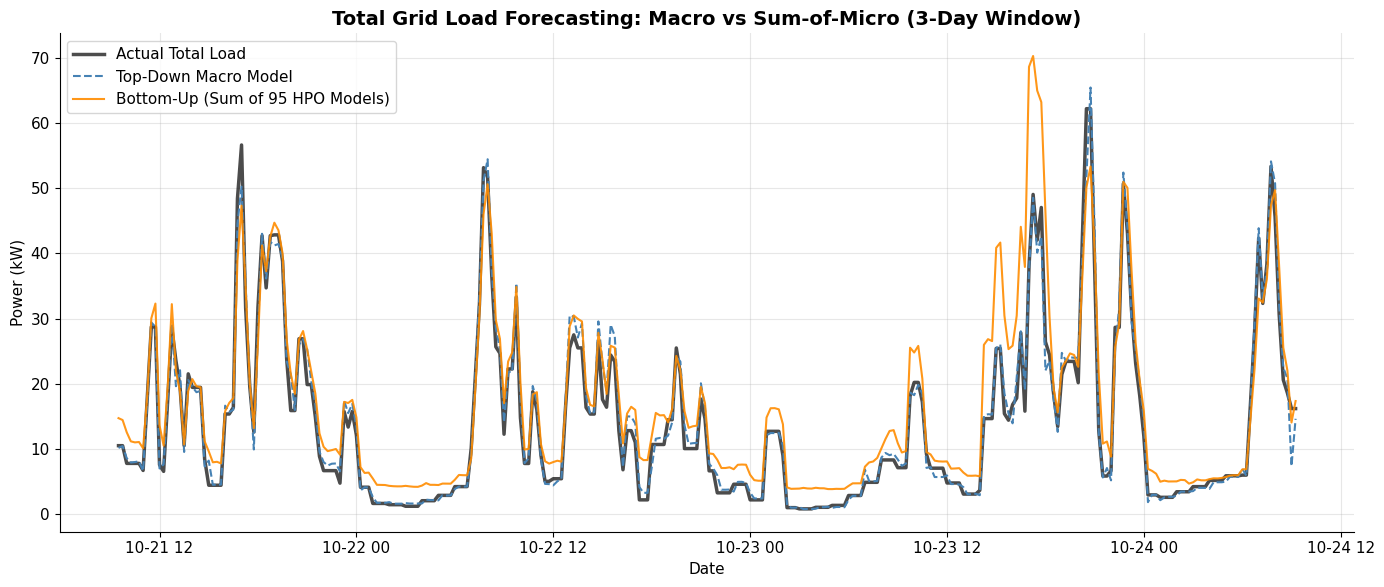


Final pipeline comparison complete.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# 13. Grid-Level Aggregate Comparison (CSVs)
# ═══════════════════════════════════════════════════════════════════════════

print("Loading finalized forecasts from CSV exports...")

# 1. Load actuals from the pre-existing test DataFrame
actual_grid_load = test_df["total_load_kW"]

# 2. Load Macro (Top-Down) combined load predictions
macro_path = os.path.join(DATA_DIR, "forecasts", "macro_model", "combined_load_forecast_15min.csv")
macro_df = pd.read_csv(macro_path, index_col="date", parse_dates=True)
macro_grid_load = macro_df.sum(axis=1)

# 3. Load Micro (Bottom-Up) combined load predictions
micro_path = os.path.join(DATA_DIR, "forecasts", "per_house_models", "combined_load_forecast_15min.csv")
micro_df = pd.read_csv(micro_path, index_col="date", parse_dates=True)
micro_grid_load = micro_df.sum(axis=1)

print("Calculating whole-system aggregate performance...")

# Metrics function
def get_metrics_agg(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": root_mean_squared_error(actual, predicted),
        "R2": r2_score(actual, predicted)
    }

macro_metrics = get_metrics_agg(actual_grid_load, macro_grid_load)
micro_metrics = get_metrics_agg(actual_grid_load, micro_grid_load)

print("\n" + "─"*80)
print("GRAND AGGREGATE GRID LOAD PERFORMANCE (Summing the 95 files)")
print("─"*80)
# Showing Macro model aggregate (this should match the single Top Model performance perfectly)
print(f"Top-Down (Macro Export)   -> R2: {macro_metrics['R2']:7.4f} | RMSE: {macro_metrics['RMSE']:6.2f} kW | MAE: {macro_metrics['MAE']:6.2f} kW")
# Showing Micro model aggregate (sum of 95 independently optimized HPO runs)
print(f"Bottom-Up (Micro Export)  -> R2: {micro_metrics['R2']:7.4f} | RMSE: {micro_metrics['RMSE']:6.2f} kW | MAE: {micro_metrics['MAE']:6.2f} kW")

if macro_metrics['MAE'] < micro_metrics['MAE']:
    print("\n-> OVERALL WINNER FOR GRAND AGGREGATE PREDICTION: Top-Down Macro Model")
    print("   Even with strict per-house hyperparameter optimization, the random noise at the")
    print("   individual node level introduces compound errors when scaled fully up up.")
else:
    print("\n-> OVERALL WINNER FOR GRAND AGGREGATE PREDICTION: Bottom-Up Micro Models")
    print("   The localized optimization patterns were successfully capable of aggregating ")
    print("   up to beat the single centralized macro curve.")

# Plotting the aggregate results for a visual 3-day verification window
plot_len = 96 * 3  # 3 days
t_plot = actual_grid_load.index[:plot_len]

plt.figure(figsize=(14, 6))
plt.title("Total Grid Load Forecasting: Macro vs Sum-of-Micro (3-Day Window)", fontsize=14, fontweight="bold")
plt.plot(t_plot, actual_grid_load[:plot_len], label="Actual Total Load", color="black", linewidth=2.5, alpha=0.7)
plt.plot(t_plot, macro_grid_load[:plot_len], label="Top-Down Macro Model", color="steelblue", linewidth=1.5, ls="--")
plt.plot(t_plot, micro_grid_load[:plot_len], label="Bottom-Up (Sum of 95 HPO Models)", color="darkorange", linewidth=1.5, alpha=0.9)

plt.ylabel("Power (kW)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal pipeline comparison complete.")